In [12]:
import os
import csv
import cv2
import numpy as np

def yolo_to_xyxy(box, img_w, img_h):

    cls, x_c, y_c, w, h = box

    x1 = (x_c - w/2) * img_w
    y1 = (y_c - h/2) * img_h
    x2 = (x_c + w/2) * img_w
    y2 = (y_c + h/2) * img_h

    return int(cls), x1, y1, x2, y2


def labels_to_csv(labels_dir, images_dir, output_csv):

    with open(output_csv, "w", newline="") as f:

        writer = csv.writer(f)

        writer.writerow(["image","cls","conf","x1","y1","x2","y2"])

        for file in os.listdir(labels_dir):

            if not file.endswith(".txt"):
                continue

            img_name = file.replace(".txt", ".jpg")
            img_path = os.path.join(images_dir, img_name)

            print("Trying:", img_path)
            print("Exists:", os.path.exists(img_path))
            if os.path.exists(img_path) == False:
                continue
            img = cv2.imdecode(
                np.fromfile(img_path, dtype=np.uint8),
                cv2.IMREAD_COLOR
            )

            if img is None:
                print(f"⚠️ image not found: {img_name}")
                continue

            h, w = img.shape[:2]

            label_path = os.path.join(labels_dir, file)

            with open(label_path) as lf:

                for line in lf:

                    parts = list(map(float, line.strip().split()))

                    cls, x1, y1, x2, y2 = yolo_to_xyxy(parts, w, h)

                    writer.writerow([
                        img_name,
                        cls,
                        1.0,   # GT → confidence = 1
                        x1,
                        y1,
                        x2,
                        y2
                    ])

    print(f"✅ Saved GT CSV → {output_csv}")

In [13]:
labels_dir = r"C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\labels\train2017"
images_dir = r"C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017"

labels_to_csv(labels_dir, images_dir, "gt.csv")

Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000009.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000025.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000030.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000034.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000036.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000042.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\train2017\000000000049.jpg
Exists: True
Trying: C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\experiments\coco128\coco128\images\

In [14]:
path = "..\services\detector_service\detections2.csv"

bboxes = []

with open(path) as f:
    reader = csv.DictReader(f)
    for row in reader:
        bboxes.append([
            float(row["x1"]),
            float(row["y1"]),
            float(row["x2"]),
            float(row["y2"])
        ])


In [15]:
import requests
import json
import csv
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [ ]:
url = "http://localhost:8080/process-bboxes"

response = requests.post(url, json=bboxes)

print(response.json())

[[302.95633245031104, -1.612323416901262, 625.4563934854673, 236.4630092247003], [254.79259316846174, 235.92019166548687, 566.6684324018602, 481.41323365767437], [1.3133111612149833, 4.353662740173036, 457.70289856355873, 460.62124086517304], [-1.7436441011037687, 112.31748760021233, 228.23839630416967, 302.94467723644277], [381.3913968935808, 63.57145771880107, 595.722024334987, 357.4767921914573], [48.78086642816207, 356.86485310568816, 152.79525546624802, 415.83848591818816], [239.32392682047254, 156.35078626993038, 407.6709879776991, 352.7428608548913], [202.80218113118252, 33.58900226220854, 457.20072544270596, 351.9305549965835], [-2.3735128785929476, 15.052630241773898, 441.17147003156333, 398.2481563648208], [171.63341535003116, 154.71453499599198, 459.75890363128116, 636.0474054793904], [-2.715050195524668, 56.61611475915379, 457.6651377927566, 497.8204604622788], [222.65129196622905, 43.96544623748031, 574.3144389388854, 295.4785993136522], [216.16472605308576, 42.47618984856

In [20]:
import csv
import numpy as np
from collections import defaultdict

# ---------------- IoU ----------------
def compute_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = area1 + area2 - inter

    if union == 0:
        return 0

    return inter / union


# ---------------- загрузка CSV ----------------
def load_csv(path, is_pred=False):

    data = defaultdict(list)

    with open(path) as f:
        reader = csv.DictReader(f)

        for row in reader:

            img = row["image"]

            cls = int(row["cls"])

            x1 = float(row["x1"])
            y1 = float(row["y1"])
            x2 = float(row["x2"])
            y2 = float(row["y2"])

            if is_pred:
                conf = float(row["conf"])
                data[img].append([cls, conf, x1, y1, x2, y2])
            else:
                data[img].append([cls, x1, y1, x2, y2])

    return data


# ---------------- matching ----------------
def match_boxes(preds, gts, iou_thresh=0.5):

    matched = set()

    tp = 0
    fp = 0

    preds = sorted(preds, key=lambda x: -x[1])  # по confidence

    for p in preds:

        cls_p, conf, x1,y1,x2,y2 = p

        best_iou = 0
        best_idx = -1

        for i, g in enumerate(gts):

            if i in matched:
                continue

            cls_g, gx1,gy1,gx2,gy2 = g

            if cls_p != cls_g:
                continue

            iou = compute_iou([x1,y1,x2,y2],[gx1,gy1,gx2,gy2])

            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_iou >= iou_thresh:
            tp += 1
            matched.add(best_idx)
        else:
            fp += 1

    fn = len(gts) - len(matched)

    return tp, fp, fn


# ---------------- precision recall f1 ----------------
def compute_metrics(tp, fp, fn):

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1


# ---------------- mAP@0.5 ----------------
def compute_map(pred_data, gt_data, iou_thresh=0.5):

    all_scores = []
    all_labels = []

    for img in gt_data:

        preds = pred_data.get(img, [])
        gts = gt_data[img]

        matched = set()

        preds = sorted(preds, key=lambda x: -x[1])

        for p in preds:

            cls_p, conf, x1,y1,x2,y2 = p

            best_iou = 0
            best_idx = -1

            for i, g in enumerate(gts):

                if i in matched:
                    continue

                cls_g, gx1,gy1,gx2,gy2 = g

                if cls_p != cls_g:
                    continue

                iou = compute_iou([x1,y1,x2,y2],[gx1,gy1,gx2,gy2])

                if iou > best_iou:
                    best_iou = iou
                    best_idx = i

            if best_iou >= iou_thresh:
                all_scores.append(conf)
                all_labels.append(1)
                matched.add(best_idx)
            else:
                all_scores.append(conf)
                all_labels.append(0)

    # сортировка
    sorted_idx = np.argsort(-np.array(all_scores))

    tp = np.array(all_labels)[sorted_idx]
    fp = 1 - tp

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)

    recall = tp_cum / (tp_cum[-1] + 1e-8)
    precision = tp_cum / (tp_cum + fp_cum + 1e-8)

    ap = np.trapz(precision, recall)

    return ap


# ---------------- main ----------------

gt = load_csv(r"C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\scripts\gt.csv", is_pred=False)
pred = load_csv(r"C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\services\detector_service\detections2.csv", is_pred=True)

total_tp, total_fp, total_fn = 0,0,0

ious = []

for img in gt:

    preds = pred.get(img, [])
    gts = gt[img]

    tp, fp, fn = match_boxes(preds, gts)

    total_tp += tp
    total_fp += fp
    total_fn += fn

    # IoU для matched
    for p in preds:
        for g in gts:
            if p[0] == g[0]:
                ious.append(compute_iou(p[2:], g[1:]))

precision, recall, f1 = compute_metrics(total_tp, total_fp, total_fn)
map50 = compute_map(pred, gt)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("mAP@0.5:", map50)
print("Mean IoU:", np.mean(ious))

Precision: 0.7689713321961388
Recall: 0.490850376743909
F1: 0.5992115589677374
mAP@0.5: 0.9297414978720772
Mean IoU: 0.14928171487629194


C:\Users\dstep\AppData\Local\Temp\ipykernel_19264\85408641.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)


In [21]:
import requests
import numpy as np

def apply_watermark_to_predictions(pred_data):

    watermarked = {}

    for img, boxes in pred_data.items():

        # берём только координаты
        coords = [b[2:] for b in boxes]

        if len(coords) == 0:
            watermarked[img] = []
            continue

        # запрос к сервису
        response = requests.post(
            "http://localhost:8080/process-bboxes",
            json=coords
        )

        shifted = response.json()

        new_boxes = []

        for i, b in enumerate(boxes):

            cls, conf = b[0], b[1]
            x1,y1,x2,y2 = shifted[i]

            new_boxes.append([cls, conf, x1, y1, x2, y2])

        watermarked[img] = new_boxes

    return watermarked

In [22]:
gt = load_csv(r"C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\scripts\gt.csv", is_pred=False)
pred = load_csv(r"C:\Users\dstep\OneDrive\Рабочий стол\лабы\НИРС\services\detector_service\detections2.csv", is_pred=True)

# baseline
print("=== BASELINE ===")

precision, recall, f1 = compute_metrics(
    *[sum(x) for x in zip(*[
        match_boxes(pred.get(img, []), gt[img])
        for img in gt
    ])]
)

map50 = compute_map(pred, gt)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("mAP:", map50)

=== BASELINE ===
Precision: 0.7689713321961388
Recall: 0.490850376743909
F1: 0.5992115589677374
mAP: 0.9297414978720772


C:\Users\dstep\AppData\Local\Temp\ipykernel_19264\85408641.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)


In [23]:
print("\n=== WATERMARK ===")

pred_wm = apply_watermark_to_predictions(pred)

total_tp, total_fp, total_fn = 0,0,0

for img in gt:

    tp, fp, fn = match_boxes(
        pred_wm.get(img, []),
        gt[img]
    )

    total_tp += tp
    total_fp += fp
    total_fn += fn

precision_w, recall_w, f1_w = compute_metrics(
    total_tp, total_fp, total_fn
)

map50_w = compute_map(pred_wm, gt)

print("Precision:", precision_w)
print("Recall:", recall_w)
print("F1:", f1_w)
print("mAP:", map50_w)


=== WATERMARK ===
Precision: 0.7689713321961388
Recall: 0.490850376743909
F1: 0.5992115589677374
mAP: 0.9297414978720772


C:\Users\dstep\AppData\Local\Temp\ipykernel_19264\85408641.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)


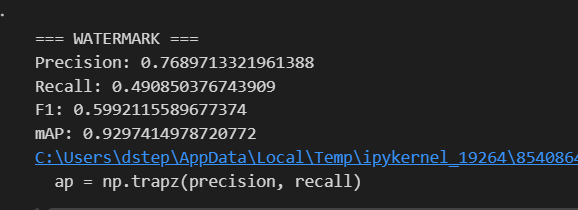

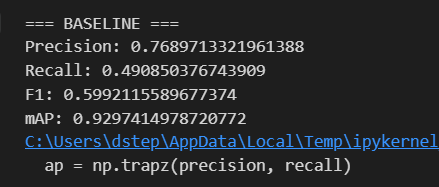

In [24]:
for img in list(gt.keys())[:3]:

    print("BEFORE:", pred[img][0])
    print("AFTER :", pred_wm[img][0])

BEFORE: [45, 0.9276054501533508, 306.1712646484375, 0.0399627685546875, 628.6713256835938, 238.11529541015625]
AFTER : [45, 0.9276054501533508, 302.95633245031104, -1.612323416901262, 625.4563934854673, 236.4630092247003]
BEFORE: [23, 0.9012081623077393, 383.3902587890625, 64.207275390625, 597.7208862304688, 358.11260986328125]
AFTER : [23, 0.9012081623077393, 383.80072321951303, 65.25766274183499, 598.1313506609192, 359.16299721449127]
BEFORE: [75, 0.8921616673469543, 239.98179626464844, 155.1142120361328, 408.328857421875, 351.50628662109375]
AFTER : [75, 0.8921616673469543, 240.44369889251294, 156.9271377933969, 408.7907600497395, 353.31921237835786]
